# Benchmark v5 — CPU — BBBP — random split, seed 4

**Task:** Binary classification — permeable (1) vs. non-permeable (0)
**Size:** ~2,039 molecules
**Metric:** ROC-AUC ↑

**Random split** (80/10/10), seed **4**. Tabular HPO on train; metrics on the held-out test set.

Results go to `results/seed_4/random/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (CPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (CPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "bbbp"
TASK_TYPE = "classification"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 100
LSTM_EPOCHS = 100
TOX21_TABULAR = False

SPLIT_MODE = "random"   # "scaffold" or "random"
SPLIT_SEED = 4

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "cpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random
Resuming 7 saved model(s): Morgan + RF, Morgan + SVM, Morgan + XGBoost, Descriptors + RF, Descriptors + SVM, Descriptors + XGBoost, Combined + XGBoost
SPLIT_SEED=4  mode=random


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("bbbp", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "bbbp")
print(f"Molecules : {len(smiles)}")
print(f"Class balance: {np.bincount(y.astype(int))}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'bbbp' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/bbbp.csv
[15:36:54] Explicit valence for atom # 1 N, 4, is greater than permitted
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] Explicit valence for atom # 6 N, 4, is greater than permitted
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydrogen atom without neighbors
[15:36:54] WARNING: not removing hydr

Molecules : 2039
Class balance: [ 479 1560]
After bond filter: 2039 molecules


[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors


### Random split


In [4]:
split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
# Guard: v4's malformed-split failure mode can never pass silently now.
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])


INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/splits/bbbp_random_splits.pkl


{'n_total': 2039, 'n_train': 1631, 'n_val': 203, 'n_test': 205, 'n_scaffolds_total': 1025, 'n_scaffolds_train': 881, 'n_scaffolds_val': 151, 'n_scaffolds_test': 154}


### Representations


In [5]:
X_morgan = smiles_to_morgan(smiles)
X_desc = smiles_to_descriptors(smiles)
X_combined = smiles_to_combined(smiles)
print(X_morgan.shape, X_desc.shape, X_combined.shape)


[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not removing hydrogen atom without neighbors
[15:36:55] WARNING: not r

(2039, 2048) (2039, 217) (2039, 2265)


### Morgan + RF


In [6]:
MODEL_KEY = "Morgan + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Morgan + RF — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Morgan + SVM


In [7]:
MODEL_KEY = "Morgan + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Morgan + SVM — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Morgan + XGBoost


In [8]:
MODEL_KEY = "Morgan + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Morgan + XGBoost — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Descriptors + RF


In [9]:
MODEL_KEY = "Descriptors + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Descriptors + RF — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Descriptors + SVM


In [10]:
MODEL_KEY = "Descriptors + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Descriptors + SVM — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Descriptors + XGBoost


In [11]:
MODEL_KEY = "Descriptors + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Descriptors + XGBoost — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Combined + XGBoost


In [12]:
MODEL_KEY = "Combined + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_combined, train_idx)
    X_te = subset_array(X_combined, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


Skipping Combined + XGBoost — already in /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_partial.json


### Finalize CPU track


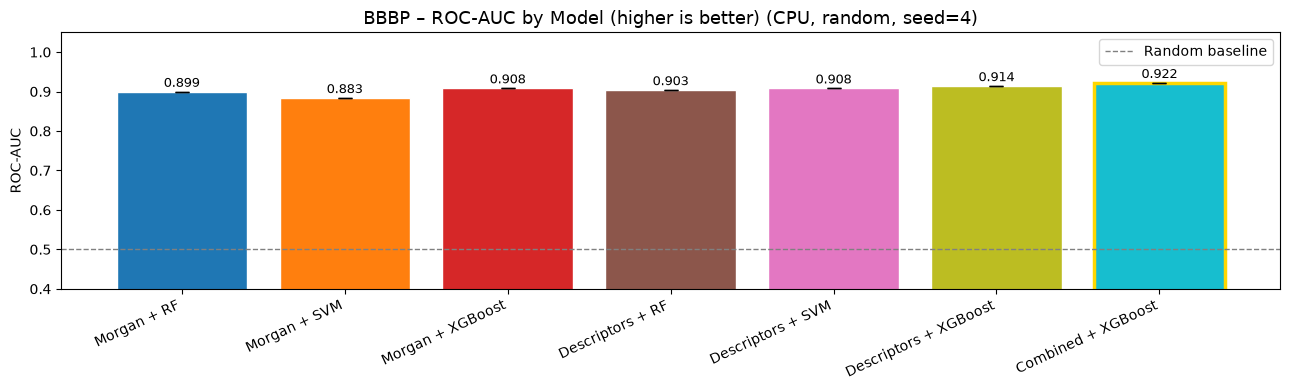

=== BBBP Results (7/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.8991 ± 0.0000  0.9706 ± 0.0000
Morgan + SVM           0.8833 ± 0.0000  0.9646 ± 0.0000
Morgan + XGBoost       0.9080 ± 0.0000  0.9752 ± 0.0000
Descriptors + RF       0.9034 ± 0.0000  0.9724 ± 0.0000
Descriptors + SVM      0.9077 ± 0.0000  0.9763 ± 0.0000
Descriptors + XGBoost  0.9136 ± 0.0000  0.9784 ± 0.0000
Combined + XGBoost     0.9217 ± 0.0000  0.9803 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/random/cpu/bbbp_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v

,ROC-AUC,PRC-AUC
Model,,
Morgan + RF,0.8991 ± 0.0000,0.9706 ± 0.0000
Morgan + SVM,0.8833 ± 0.0000,0.9646 ± 0.0000
Morgan + XGBoost,0.9080 ± 0.0000,0.9752 ± 0.0000
Descriptors + RF,0.9034 ± 0.0000,0.9724 ± 0.0000
Descriptors + SVM,0.9077 ± 0.0000,0.9763 ± 0.0000
Descriptors + XGBoost,0.9136 ± 0.0000,0.9784 ± 0.0000
Combined + XGBoost,0.9217 ± 0.0000,0.9803 ± 0.0000


In [13]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE, plot_title=f"BBBP – ROC-AUC by Model (higher is better) (CPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
